/tmp/ipykernel_2110/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2110/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2110/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2110/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2110/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2110/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


--- slotted 10B : LoRa_NS_DER ---
      N     value
0    20  0.885601
1    50  0.834115
2   100  0.756436
3   200  0.601214
4   400  0.353046
5   600  0.229626
6   800  0.131154
7  1000  0.068419

--- slotted 10B : énergie par nœud (J) ---
      N     value
0    20  0.684984
1    50  0.685466
2   100  0.689343
3   200  0.688558
4   400  0.694056
5   600  0.678579
6   800  0.685288
7  1000  0.695376

--- slotted 28B : LoRa_NS_DER ---
     N     value
0   20  0.885011
1   50  0.831219
2  100  0.754899
3  200  0.604778
4  400  0.359784
5  600  0.220264
6  800  0.126312

--- slotted 28B : énergie par nœud (J) ---
     N     value
0   20  0.924988
1   50  0.925793
2  100  0.931207
3  200  0.929353
4  400  0.938567
5  600  0.914278
6  800  0.927457

--- slotted 59B : LoRa_NS_DER ---
      N     value
0    20  0.859865
1    50  0.806676
2   100  0.715776
3   200  0.567586
4   400  0.324511
5   600  0.189648
6   800  0.112583
7  1000  0.067702

--- slotted 59B : énergie par nœud (J) ---
     

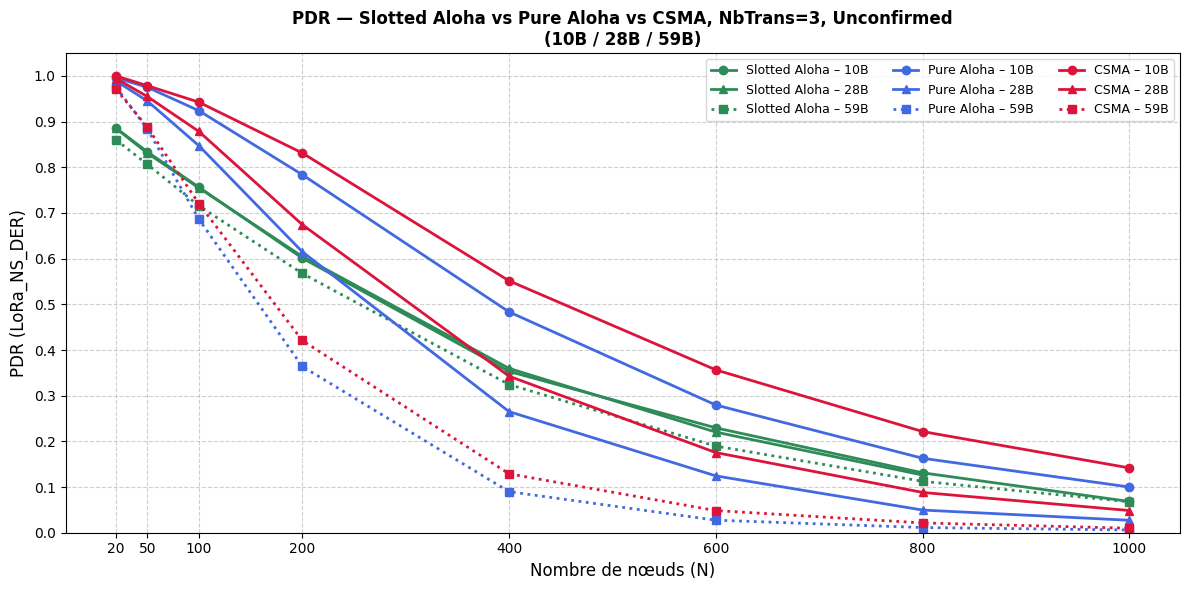

[OK] Figure sauvegardée : pdr_slotted_aloha_csma_payload.png


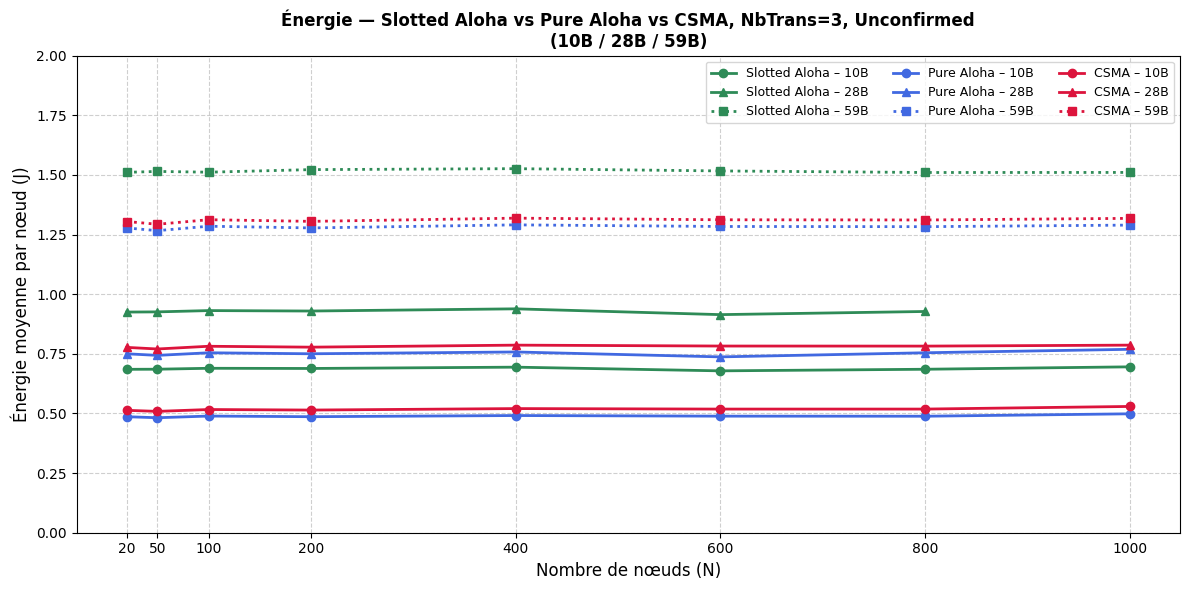

[OK] Figure sauvegardée : energy_slotted_aloha_csma_payload.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ================================
# Chemins des CSV pour chaque protocole / payload
# ================================
PATHS = {
    "slotted": {
        "10B": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
    "aloha": {
        "10B": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "10B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ================================
# Helpers
# ================================
def get_results(csv_path, scalar_name, module_filter=None):
    if not os.path.exists(csv_path):
        print(f"[WARN] Fichier introuvable : {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_energy_per_node(csv_path, with_csma_energy=False):
    if not os.path.exists(csv_path):
        print(f"[WARN] Fichier introuvable : {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    mask_e = (df["name"] == "totalEnergyConsumed") & df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})
    if sub_e.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if not sub_c.empty:
            sub_e = sub_e.merge(sub_c, on=["run", "module"], how="left")
            sub_e["csma_energy"] = sub_e["csma_energy"].fillna(0)
            sub_e["energy"] = sub_e["energy"] + sub_e["csma_energy"]

    sub_e["node_idx"] = sub_e["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub_e["N"] = sub_e["run"].map(N_dict)
    sub_e = sub_e.dropna(subset=["N", "node_idx"])
    sub_e = sub_e[sub_e["node_idx"] < sub_e["N"]]

    mean_per_run = sub_e.groupby(["run", "N"])["energy"].mean().reset_index()
    return (mean_per_run.groupby("N", as_index=False)["energy"]
            .mean().sort_values("N").rename(columns={"energy": "value"}))


def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der


# ================================
# Chargement des données
# ================================
PROTOCOLS = ["slotted", "aloha", "csma"]
PAYLOADS = ["10B", "28B", "59B"]

der = {
    proto: {p: load_der(PATHS[proto][p]) for p in PAYLOADS}
    for proto in PROTOCOLS
}
energy = {
    proto: {p: get_energy_per_node(PATHS[proto][p], with_csma_energy=(proto == "csma")) for p in PAYLOADS}
    for proto in PROTOCOLS
}

# ================================
# Affichage console
# ================================
for proto in PROTOCOLS:
    for p in PAYLOADS:
        print(f"\n--- {proto} {p} : LoRa_NS_DER ---")
        print(der[proto][p])
        print(f"\n--- {proto} {p} : énergie par nœud (J) ---")
        print(energy[proto][p])

# ================================
# Style visuel
# ================================
# Couleur  → payload   : bleu=10B, rouge=28B, vert=59B
# Trait    → protocole : continu=Slotted Aloha, pointillé=Pure Aloha, tirets=CSMA
# Marqueur → payload   : o=10B, ^=28B, s=59B

# Couleur = protocole
PROTO_COLOR = {
    "aloha": "royalblue",      # Pure Aloha
    "slotted": "seagreen",     # Slotted Aloha
    "csma": "crimson",         # CSMA
}

# Marqueur = payload
PAYLOAD_MARKER = {
    "10B": "o",
    "28B": "^",
    "59B": "s",
}

# Style de ligne = payload
PAYLOAD_LS = {
    "10B": "-",
    "28B": "-",
    "59B": ":",
}
PROTO_LABEL = {
    "slotted": "Slotted Aloha",
    "aloha":   "Pure Aloha",
    "csma":    "CSMA",
}

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

for proto in PROTOCOLS:
    for payload in PAYLOADS:
        df = der[proto][payload]
        if df.empty:
            continue
        ax1.plot(
            df["N"], df["value"],
            color=PROTO_COLOR[proto],
            marker=PAYLOAD_MARKER[payload],
            linestyle=PAYLOAD_LS[payload],
            linewidth=2,
            label=f"{PROTO_LABEL[proto]} – {payload}"
        )

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("PDR — Slotted Aloha vs Pure Aloha vs CSMA, NbTrans=3, Unconfirmed\n(10B / 28B / 59B)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_slotted_aloha_csma_payload.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : pdr_slotted_aloha_csma_payload.png")

# ================================
# Figure 2 : Énergie
# ================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

for proto in PROTOCOLS:
    for payload in PAYLOADS:
        df = energy[proto][payload]
        if df.empty:
            continue
        ax2.plot(
            df["N"], df["value"],
            color=PROTO_COLOR[proto],
            marker=PAYLOAD_MARKER[payload],
            linestyle=PAYLOAD_LS[payload],
            linewidth=2,
            label=f"{PROTO_LABEL[proto]} – {payload}"
        )

ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_ylim(0, 2)
ax2.set_title("Énergie — Slotted Aloha vs Pure Aloha vs CSMA, NbTrans=3, Unconfirmed\n(10B / 28B / 59B)",
              fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=9, ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_slotted_aloha_csma_payload.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : energy_slotted_aloha_csma_payload.png")

/tmp/ipykernel_867/3937444764.py:16: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_867/3937444764.py:16: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_867/3937444764.py:43: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_867/3937444764.py:75: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



--- Aloha : energie par noeud (J) ---
   N    value
  20 0.169658
  50 0.169027
 100 0.171571
 200 0.170290
 400 0.171014
 600 0.170196
 800 0.170718
1000 0.170997

--- CSMA : energie corrigée par noeud (J) [totalEnergy + CSMA] ---
   N    value
  20 0.178944
  50 0.178324
 100 0.180940
 200 0.179641
 400 0.180393
 600 0.179557
 800 0.180102
1000 0.180395


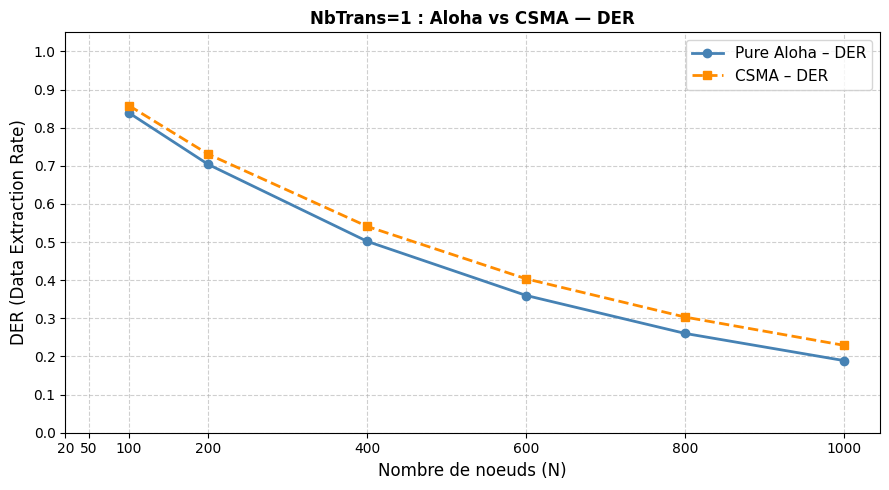

[OK] Figure sauvegardee : der_aloha_vs_csma.png


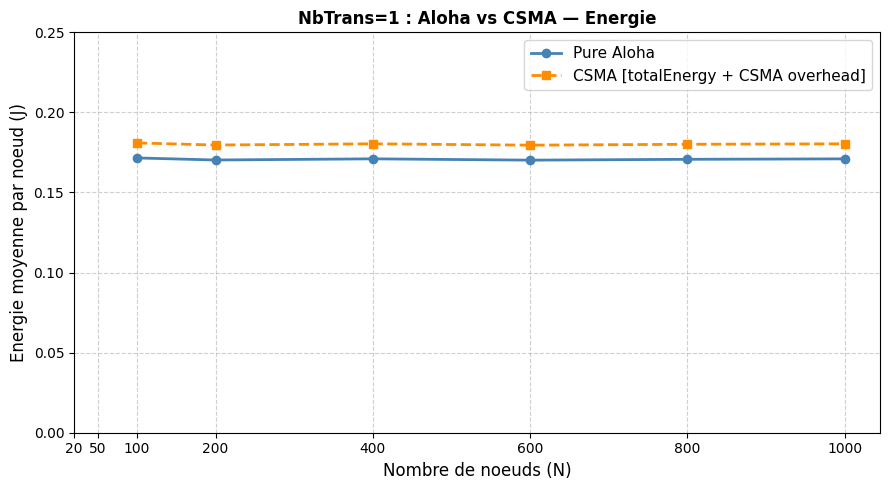

[OK] Figure sauvegardee : energy_aloha_vs_csma.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

PATH_ALOHA = os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_CSMA  = os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv")
custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]


# ================================
# Fonction générique (DER, etc.)
# ================================
def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


# ================================
# Énergie ALOHA : totalEnergyConsumed seul
# ================================
def get_energy_aloha(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()

    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]

    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result


# ================================
# Énergie CSMA : totalEnergyConsumed + Total CSMA Energy (J)
# ================================
def get_energy_csma(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    mask_e = (df["name"] == "totalEnergyConsumed") & \
             (df["module"].str.contains("loRaNodes", na=False))
    sub_e = df[mask_e][["run", "module", "value"]].copy()
    sub_e = sub_e.rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    mask_c = (df["name"] == "Total CSMA Energy (J)") & \
             (df["module"].str.contains("loRaNodes", na=False))
    sub_c = df[mask_c][["run", "module", "value"]].copy()
    sub_c = sub_c.rename(columns={"value": "csma_energy"})

    if sub_c.empty:
        print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — énergie CSMA non ajoutée")
        sub_e["total"] = sub_e["energy"]
        merged = sub_e
    else:
        merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
        merged["csma_energy"] = merged["csma_energy"].fillna(0)
        merged["total"] = merged["energy"] + merged["csma_energy"]

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


# ================================
# DER : Aloha et CSMA
# ================================
der_aloha = get_results(PATH_ALOHA, "LoRa_NS_DER", module_filter="networkServer")
if der_aloha.empty:
    der_aloha = get_results(PATH_ALOHA, "LoRa_NS_DER")

der_csma = get_results(PATH_CSMA, "LoRa_NS_DER", module_filter="networkServer")
if der_csma.empty:
    der_csma = get_results(PATH_CSMA, "LoRa_NS_DER")

# ================================
# Énergie
# ================================
energy_aloha = get_energy_aloha(PATH_ALOHA)
energy_csma  = get_energy_csma(PATH_CSMA)

print("\n--- Aloha : energie par noeud (J) ---")
print(energy_aloha.to_string(index=False))
print("\n--- CSMA : energie corrigée par noeud (J) [totalEnergy + CSMA] ---")
print(energy_csma.to_string(index=False))

# ================================
# Figure 1 : DER — Aloha vs CSMA (N >= 100)
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))
if not der_aloha.empty:
    da = der_aloha[der_aloha["N"] >= 100]        # ← filtre corrigé
    ax1.plot(da["N"], da["value"],
             marker="o", color="steelblue", linewidth=2,
             label="Pure Aloha – DER")
if not der_csma.empty:
    dc = der_csma[der_csma["N"] >= 100]          # ← filtre cohérent
    ax1.plot(dc["N"], dc["value"],
             marker="s", color="darkorange", linewidth=2, linestyle="--",
             label="CSMA – DER")
ax1.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax1.set_ylabel("DER (Data Extraction Rate)", fontsize=12)
ax1.set_title("NbTrans=1 : Aloha vs CSMA — DER", fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("der_aloha_vs_csma.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardee : der_aloha_vs_csma.png")

# ================================
# Figure 2 : Energie — Aloha vs CSMA (N >= 100)
# ================================
fig2, ax2 = plt.subplots(figsize=(9, 5))
if not energy_aloha.empty:
    ea = energy_aloha[energy_aloha["N"] >= 100]  # ← >= au lieu de >
    ax2.plot(ea["N"], ea["value"],
             marker="o", color="steelblue", linewidth=2,
             label="Pure Aloha")
if not energy_csma.empty:
    ec = energy_csma[energy_csma["N"] >= 100]    # ← >= au lieu de >
    ax2.plot(ec["N"], ec["value"],
             marker="s", color="darkorange", linewidth=2, linestyle="--",
             label="CSMA [totalEnergy + CSMA overhead]")
ax2.set_xlabel("Nombre de noeuds (N)", fontsize=12)
ax2.set_ylabel("Energie moyenne par noeud (J)", fontsize=12)
ax2.set_title("NbTrans=1 : Aloha vs CSMA — Energie", fontsize=12, fontweight="bold")
ax2.set_ylim(0, 0.25)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.05))
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_aloha_vs_csma.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardee : energy_aloha_vs_csma.png")